#### timeseries plots of annual TC numbers for (historical period) IBTrACS and ERA5

Ming Ge July 2025

In [2]:
import numpy as np
import glob
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import tc_helping
from importlib import reload
reload(tc_helping)
from  tc_helping import  rd_IB_OX, rd_E5_Traj_SH

import warnings
warnings.filterwarnings("ignore")

/glade/u/home/mingge/TC/tc_helping.py:4139: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  australia_buffer_deg = australia.to_crs(epsg=4326).buffer(radius)
/glade/u/home/mingge/TC/tc_helping.py:4140: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  newzealand_buffer_deg = newzealand.to_crs(epsg=4326).buffer(radius)
/glade/u/home/mingge/TC/tc_helping.py:4139: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  australia_buffer_deg = australia.to_crs(epsg=4326).buffer(radius)
/glade/u/home/mingge/TC/tc_helping.py:4140: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' a

IBTrACS =  0.7 /year
ERA5 =  1.0 /year


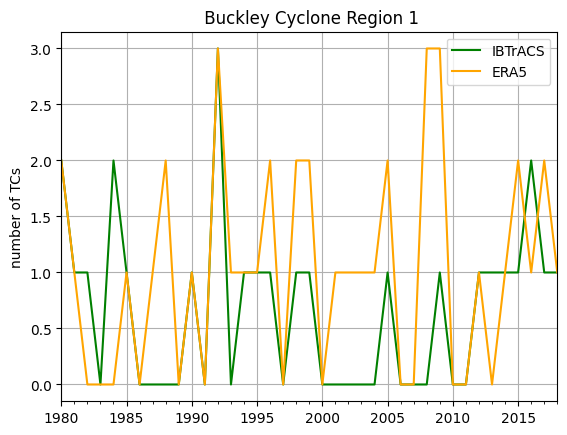

IBTrACS =  3.5 /year
ERA5 =  3.3 /year


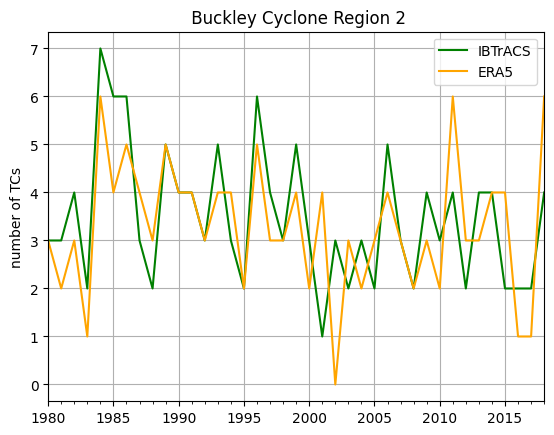

IBTrACS =  2.5 /year
ERA5 =  2.2 /year


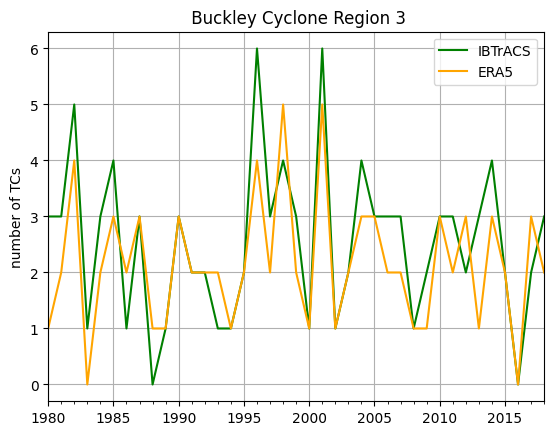

IBTrACS =  6.2 /year
ERA5 =  5.6 /year


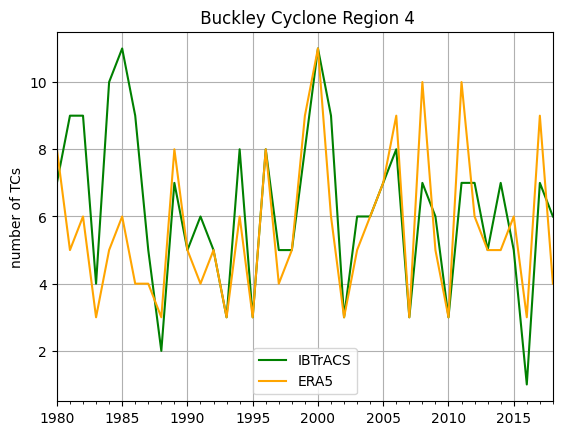

IBTrACS =  1.9 /year
ERA5 =  1.6 /year


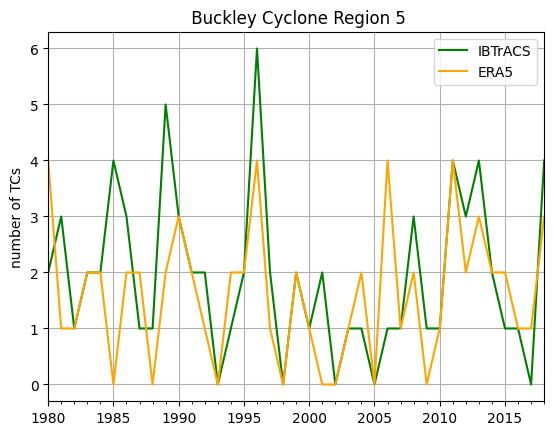

IBTrACS =  1.7 /year
ERA5 =  2.6 /year


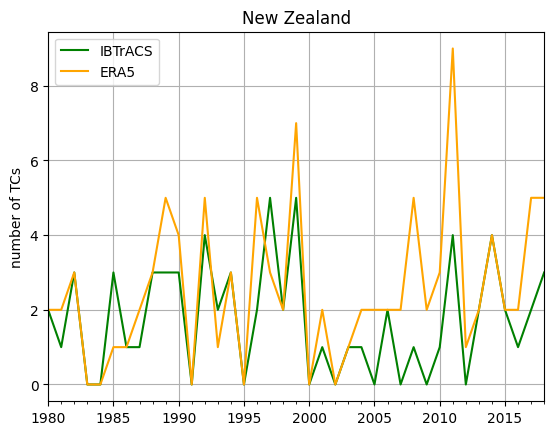

In [10]:
Australian_CAT_10min = [34, 48, 74, 97, 120, 1000]

year_s = 1980
year_e = 2018

n_year = year_e - year_s + 1

lat_s_1d = [-40, -27, -20, -25, -40, -48]
lat_e_1d = [-25, -9,  -9,  -9,  -25, -30]
lon_s_1d = [145, 143, 132, 100, 100, 163]
lon_e_1d = [160, 158, 143, 132, 145, 183] 

n_region = len(lat_s_1d)


for nr in range(n_region):
    if nr == n_region - 1:
        country_s = 'New Zealand'
        region_s = 'New Zealand'
        #print(country_s)
    else:
        country_s = 'Australia'
        region_s = ' Buckley Cyclone Region ' + str(nr + 1)
        #print(country_s  + ' Buckley Cyclone Region ' + str(nr + 1))
        
    lat_s = lat_s_1d[nr]
    lat_e = lat_e_1d[nr]
    lon_s = lon_s_1d[nr]
    lon_e = lon_e_1d[nr]
    lon_cen = (lon_s+lon_e)*0.5
        
    extent = [lon_s, lon_e, lat_s, lat_e]

    df_ib = rd_IB_OX(year_s, year_e, extent, Australian_CAT_10min[0])
    #print('IB cat1 mean=', df_ib['TC Count'].mean(), df_ib['Vmax'].mean())
    df_ib['TC Count'].plot(color='green', label='IBTrACS')
    df_e5 = rd_E5_Traj_SH(year_s, year_e, extent, 0)   
    df_e5['TC Count'].plot(color='orange', label='ERA5')
    #print('annual average number of TC ')
    print('IBTrACS = ', f"{df_ib['TC Count'].mean():.1f}", '/year')
    print( 'ERA5 = ', f"{df_e5['TC Count'].mean():.1f}", '/year')
    
     
    plt.ylabel('number of TCs')
    plt.title(region_s)
    plt.grid(True)
    plt.legend()
    plt.show()
    